LOCAL FERIA

Utilizing OpenCV and Pillow, this code below creates an application that captures live video from the webcam, displays overlaid instructions on the video feed, allows the user to save a person-free, well-framed bed calibration photo in RGB format by pressing the 'c' key, and stores the image in a specified file path.

In [1]:
import cv2
import ultralytics
import os
import PIL
import numpy as np
import math
import time
import mailtrap as mt
import requests
import torch
import math

from ultralytics import YOLO
from yolov6.utils.events import LOGGER, load_yaml
from yolov6.layers.common import DetectBackend
from yolov6.data.data_augment import letterbox
from yolov6.utils.nms import non_max_suppression
from yolov6.core.inferer import Inferer
from typing import List, Optional

In [3]:
class PhotoCaptureApp:
    def __init__(self, save_folder):
        self.save_folder = save_folder

        # Set up OpenCV to capture video
        self.cap = cv2.VideoCapture(0)

        while not self.cap.isOpened():
            pass

        # Set the window size
        self.cap.set(3, 640)
        self.cap.set(4, 480)

        # Define font and color
        self.font = cv2.FONT_HERSHEY_SIMPLEX
        self.font_size = 0.8
        self.font_thickness = 2
        self.font_color = (57, 255, 20)  # Neon Green
        self.font_outline_thickness = 3
        self.font_outline_color = (0, 0, 0)

    def update(self):
        ret, frame = self.cap.read()

        if ret:
            # Convert BGR image to RGB
            img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Add text to the image
            text_line1 = "Capture a person-free, well-framed"
            text_line2 = "bed calibration photo by pressing 'c'."
            text = f"{text_line1}\n{text_line2}"

            text_position = (10, 20)  # Adjusted position

            cv2.putText(img, text_line1, (text_position[0], text_position[1] + 30), self.font, self.font_size,
                        self.font_outline_color, self.font_outline_thickness, cv2.LINE_AA)
            cv2.putText(img, text_line2, (text_position[0], text_position[1] + 60), self.font, self.font_size,
                        self.font_outline_color, self.font_outline_thickness, cv2.LINE_AA)

            cv2.putText(img, text_line1, (text_position[0], text_position[1] + 30), self.font, self.font_size,
                        self.font_color, self.font_thickness, cv2.LINE_AA)
            cv2.putText(img, text_line2, (text_position[0], text_position[1] + 60), self.font, self.font_size,
                        self.font_color, self.font_thickness, cv2.LINE_AA)

            # Save the image without overlay text directly to the specified folder
            save_path = os.path.join(self.save_folder, "calibration_image.jpg")
            cv2.imwrite(save_path, frame)

            # Display the image in a separate OpenCV window (converted back to BGR for display)
            cv2.imshow("Photo Capture", cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    def run(self):
        while True:
            self.update()
            key = cv2.waitKey(1) & 0xFF
            if key == ord('c'):
                # Capture the current frame, save it, and exit
                ret, frame = self.cap.read()
                if ret:
                    # Save the image directly to the specified folder
                    save_path = os.path.join(self.save_folder, "calibration_image.jpg")
                    cv2.imwrite(save_path, frame)
                    print(f"Image saved to {save_path}")
                    break

        # Release the camera and close OpenCV windows
        self.cap.release()
        cv2.destroyAllWindows()

if __name__ == "__main__":
    save_folder = "data/yolov6/fotos_out/crop_out/bed_calibration"
    app = PhotoCaptureApp(save_folder)
    app.run()

Image saved to data/yolov6/fotos_out/crop_out/bed_calibration/calibration_image.jpg


The code sets up and runs YOLOv6 Lite on a provided image for object detection, displaying the inference results with bounding boxes and class labels.

sh: wget: command not found
checkpoint yolov6n.pt not exist, try to downloaded it from github.
downloading url is: https://github.com/meituan/YOLOv6/releases/download/0.4.0/yolov6n.pt, pealse make sure the version of the downloading model is correspoing to the code version!


checkpoint yolov6n.pt downloaded and saved
Loading checkpoint from ./yolov6n.pt

Fusing model...
/Users/emibetroldan/YEM/YEM/.conda/lib/python3.12/site-packages/torch/nn/modules/module.py:836: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  if param.grad is not None:


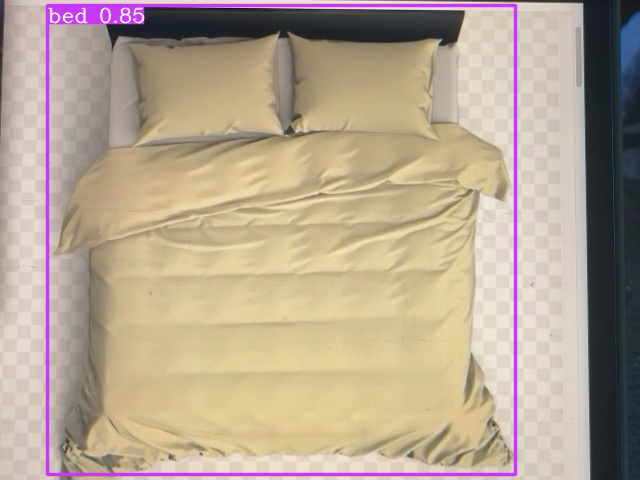

In [4]:
#@title Set-up model. { run: "auto" }
checkpoint:str ="yolov6n" #@param ["yolov6s", "yolov6n", "yolov6t"]
device:str = "cpu"#@param ["gpu", "cpu"]
half:bool = False #@param {type:"boolean"}

#Change directory so that imports wortk correctly
if os.getcwd()=="/content":
  os.chdir("YOLOv6")

# Set the local image path
image_path = "data/yolov6/fotos_out/crop_out/bed_calibration/calibration_image.jpg"

# Download weights
if not os.path.exists(f"{checkpoint}.pt"):
  print("Downloading checkpoint...")
  os.system(f"""wget -c https://github.com/meituan/YOLOv6/releases/download/0.4.0/{checkpoint}.pt""")

# Set-up hardware options
cuda = device != 'cpu' and torch.cuda.is_available()
device = torch.device('cuda:0' if cuda else 'cpu')

def check_img_size(img_size, s=32, floor=0):
  def make_divisible( x, divisor):
    # Upward revision the value x to make it evenly divisible by the divisor.
    return math.ceil(x / divisor) * divisor
  """Make sure image size is a multiple of stride s in each dimension, and return a new shape list of image."""
  if isinstance(img_size, int):  # integer i.e. img_size=640
      new_size = max(make_divisible(img_size, int(s)), floor)
  elif isinstance(img_size, list):  # list i.e. img_size=[640, 480]
      new_size = [max(make_divisible(x, int(s)), floor) for x in img_size]
  else:
      raise Exception(f"Unsupported type of img_size: {type(img_size)}")

  if new_size != img_size:
      print(f'WARNING: --img-size {img_size} must be multiple of max stride {s}, updating to {new_size}')
  return new_size if isinstance(img_size,list) else [new_size]*2


def process_image(path, img_size, stride, half):
  '''Process image before image inference.'''
  try:
    img_src = np.asarray(PIL.Image.open(path))
    assert img_src is not None, f'Invalid image: {path}'
  except Exception as e:
    LOGGER.warning(e)
    return None, None  # Return None for both image and img_src in case of an exception

  image = letterbox(img_src, img_size, stride=stride)[0]

  # Convert
  image = image.transpose((2, 0, 1))  # HWC to CHW
  image = torch.from_numpy(np.ascontiguousarray(image))
  image = image.half() if half else image.float()  # uint8 to fp16/32
  image /= 255  # 0 - 255 to 0.0 - 1.0

  return image, img_src


model = DetectBackend(f"./{checkpoint}.pt", device=device)
stride = model.stride
class_names = load_yaml("data/yolov6/data/coco.yaml")['names']

if half & (device.type != 'cpu'):
  model.model.half()
else:
  model.model.float()
  half = False

img_size:int = 640#@param {type:"integer"}

if device.type != 'cpu':
  model(torch.zeros(1, 3, *img_size).to(device).type_as(next(model.model.parameters())))  # warmup

#@title Run YOLOv6 on an image from a local path. { run: "auto" }
hide_labels: bool = False #@param {type:"boolean"}
hide_conf: bool = False #@param {type:"boolean"}

img_size:int = 640#@param {type:"integer"}

conf_thres: float =.60 #@param {type:"number"}
iou_thres: float =.80 #@param {type:"number"}
max_det:int =  1000#@param {type:"integer"}
agnostic_nms: bool = False #@param {type:"boolean"}

img_size = check_img_size(img_size, s=stride)

img, img_src = process_image(image_path, img_size, stride, half)
img = img.to(device)
if len(img.shape) == 3:
    img = img[None]
    # expand for batch dim
pred_results = model(img)
classes:Optional[List[int]] = None # the classes to keep
det = non_max_suppression(pred_results, conf_thres, iou_thres, classes, agnostic_nms, max_det=max_det)[0]

gn = torch.tensor(img_src.shape)[[1, 0, 1, 0]]  # normalization gain whwh
img_ori = img_src.copy()
if len(det):
  det[:, :4] = Inferer.rescale(img.shape[2:], det[:, :4], img_src.shape).round()
  for *xyxy, conf, cls in reversed(det):
      class_num = int(cls)
      label = None if hide_labels else (class_names[class_num] if hide_conf else f'{class_names[class_num]} {conf:.2f}')
      Inferer.plot_box_and_label(img_ori, max(round(sum(img_ori.shape) / 2 * 0.003), 2), xyxy, label, color=Inferer.generate_colors(class_num, True))
PIL.Image.fromarray(img_ori)

This code processes object detection results from a YOLO model, saving the output image with bounding boxes, creating a YOLO annotation file, and cropping and saving individual detected regions based on class labels in specified folders.

In [5]:
def read_yolo_annotation(annotation_path, image_width, image_height):
    with open(annotation_path, 'r') as file:
        lines = file.readlines()

    bounding_boxes = []
    for line in lines:
        data = line.strip().split()
        class_index = int(data[0])
        x_center, y_center, width, height = map(float, data[1:])
        
        # Convert from normalized coordinates to image coordinates
        x_min = int((x_center - width / 2) * image_width)
        y_min = int((y_center - height / 2) * image_height)
        x_max = int((x_center + width / 2) * image_width)
        y_max = int((y_center + height / 2) * image_height)

        bounding_boxes.append((class_index, x_min, y_min, x_max, y_max))

    return bounding_boxes

# Function to save YOLO annotation file for the bed class only
def save_bed_annotation(annotation_path, det, img_width, img_height, bed_index):
    with open(annotation_path, 'w') as file:
        for *xyxy, conf, cls in reversed(det):
            class_num = int(cls)

            # Check if the detected class is the bed class
            if class_num == bed_index:
                # Calculate XYWH format directly from XYXY
                x_center = (xyxy[0] + xyxy[2]) / 2
                y_center = (xyxy[1] + xyxy[3]) / 2
                width = xyxy[2] - xyxy[0]
                height = xyxy[3] - xyxy[1]

                # Normalize coordinates to [0, 1]
                x_center /= img_width
                y_center /= img_height
                width /= img_width
                height /= img_height

                line = f"{class_num} {x_center} {y_center} {width} {height}\n"
                file.write(line)

# Function to generate output paths dynamically
def generate_output_paths(crop_out_folder, class_name, index):
    class_folder = os.path.join(crop_out_folder, class_name)
    os.makedirs(class_folder, exist_ok=True)
    output_path = os.path.join(class_folder, f'{class_name}_{index}.jpg')
    return output_path

# Replace these paths with your actual folder paths
jpg_output_images_folder = 'data/yolov6/fotos_out/yolo_out/jpg_files'
txt_output_annotations_folder = 'data/yolov6/fotos_out/yolo_out/txt_files'
crop_out_folder = 'data/yolov6/fotos_out/crop_out'

os.makedirs(jpg_output_images_folder, exist_ok=True)
os.makedirs(txt_output_annotations_folder, exist_ok=True)

# ...

# Save image to JPEG
output_image_path = os.path.join(jpg_output_images_folder, 'output_image.jpg')
cv2.imwrite(output_image_path, cv2.cvtColor(img_ori, cv2.COLOR_RGB2BGR))

# Save YOLO annotation file for the bed class only
output_annotation_path = os.path.join(txt_output_annotations_folder, 'output_image.txt')
save_bed_annotation(output_annotation_path, det, img_ori.shape[1], img_ori.shape[0], 59)

# Display the processed image
PIL.Image.fromarray(cv2.cvtColor(img_ori, cv2.COLOR_BGR2RGB))

# Read YOLO annotation
bounding_boxes = read_yolo_annotation(output_annotation_path, img_ori.shape[1], img_ori.shape[0])

# Crop and save regions only if the detected class is a bed
for i, (class_index, x_min, y_min, x_max, y_max) in enumerate(bounding_boxes):
    class_name = class_names[class_index]
    
    # Check if the detected class is a bed (replace 'bed_index' with the actual index of the bed class)
    if class_index == 59:
        output_path = generate_output_paths(crop_out_folder, class_name, i)
        cropped_region = img_ori[y_min:y_max, x_min:x_max]
        cv2.imwrite(output_path, cv2.cvtColor(cropped_region, cv2.COLOR_BGR2RGB))

This code reads YOLO annotation data from a text file, containing normalized coordinates, and calculates the corresponding image coordinates for bounding boxes, then prints the class names and image coordinates for each bounding box.

In [6]:
def calculate_coordinates_from_yolo_annotation(annotation_path, image_width, image_height):
    with open(annotation_path, 'r') as file:
        lines = file.readlines()

    bounding_boxes = []
    for line in lines:
        data = line.strip().split()
        class_index = int(data[0])
        x_center, y_center, width, height = map(float, data[1:])
        
        # Convert from normalized coordinates to image coordinates
        x_min = int((x_center - width / 2) * image_width)
        y_min = int((y_center - height / 2) * image_height)
        x_max = int((x_center + width / 2) * image_width)
        y_max = int((y_center + height / 2) * image_height)

        bounding_boxes.append((class_index, x_min, y_min, x_max, y_max))

    return bounding_boxes

# Replace these paths with your actual file paths
annotation_path = 'data/yolov6/fotos_out/yolo_out/txt_files/output_image.txt'
image_width = 640  # Replace with the actual width of your image
image_height = 480  # Replace with the actual height of your image

# Read YOLO annotation and calculate coordinates
bounding_boxes = calculate_coordinates_from_yolo_annotation(annotation_path, image_width, image_height)

# Print calculated bounding box coordinates
for i, (class_index, x_min, y_min, x_max, y_max) in enumerate(bounding_boxes):
    print(f"Bounding Box {i + 1}: Class {class_names[class_index]}, Coordinates (x_min, y_min, x_max, y_max): ({x_min}, {y_min}, {x_max}, {y_max})")

bed_coords = (x_min, y_min, x_max, y_max)

Bounding Box 1: Class bed, Coordinates (x_min, y_min, x_max, y_max): (47, 4, 515, 473)


Pose estimation perfect!

In [ ]:
import cv2
import time
from ultralytics import YOLO

# Permanent boundary box for bed
bed_box_coords = (bed_coords)

# Load YOLO model
model = YOLO('yolov8n-pose.pt')

# Open a connection to the camera (0 is usually the default camera)
cap = cv2.VideoCapture(1)
cap.set(3, 640)
cap.set(4, 480)

# Define variables for patient status
status = ""
status_color = (0, 0, 0)  # Default color is black

while True:

    # Read a frame from the camera
    ret, frame = cap.read()
    if not ret:
        break

    # Run inference on the current frame
    results = model(frame)

    # Extract keypoints from the first result in the list
    if results and results[0].keypoints.xy.shape[0] > 0:
        result_keypoints = results[0].keypoints.xy[0]
    else:
        result_keypoints = []

    # Convert the keypoints to a NumPy array
    result_keypoints = result_keypoints.cpu().numpy()

    # Check if keypoints are available before drawing connections
    if result_keypoints.shape[0] > 0:
        # Define colors for keypoints and lines
        colors = {
            "green": (0, 255, 0),  # Eyes, Nose, Ears
            "blue": (255, 0, 0),   # Shoulders, Elbows, Wrists
            "pink": (147, 20, 255),  # Hips, Connections to Shoulders
            "orange": (0, 165, 255)  # Knees, Ankles, Connections to Hips
        }

        # Define connections for each color
        connections = {
            "green": [(1, 0), (2, 0), (1, 3), (2, 4)],  # Connect Eyes to Nose and Ears
            "blue": [(5, 6), (5, 7), (7, 9), (6, 8), (8, 10)],  # Connect Shoulders, Elbows, Wrists
            "pink": [(11, 12), (11, 5), (12, 6)],  # Connect Hips and Shoulders
            "orange": [(11, 13), (13, 14), (14, 15), (12, 16), (16, 15)]  # Connect Hips, Knees, and Ankles
        }

        # Check the position of the visible keypoints relative to the bed boundary box
        visible_keypoints = [(x, y) for x, y in result_keypoints if x != 0 and y != 0]
        all_inside_bed = all(bed_box_coords[0] <= x <= bed_box_coords[2] and bed_box_coords[1] <= y <= bed_box_coords[3] for x, y in visible_keypoints)
        all_outside_bed = all(x < bed_box_coords[0] or x > bed_box_coords[2] or y < bed_box_coords[1] or y > bed_box_coords[3] for x, y in visible_keypoints)

        if all_inside_bed:
            status = "Patient is in bed."
            status_color = (0, 255, 0)  # Green
        elif all_outside_bed:
            status = "Alert! Patient is out of the bed!"
            status_color = (0, 0, 255)  # Red
        else:
            status = "Patient is getting out of bed!"
            status_color = (0, 165, 255)  # Orange

        # Draw keypoints and connections for visible keypoints
        for color, points in connections.items():
            for point1, point2 in points:
                x1, y1 = result_keypoints[point1]
                x2, y2 = result_keypoints[point2]
                # Check if the keypoints are visible (non-zero) before drawing
                if x1 != 0 and y1 != 0 and x2 != 0 and y2 != 0:
                    cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), colors[color], 2)

        # Draw the permanent boundary box for the bed
        bed_color = (255, 255, 255)
        bed_thickness = 2
        cv2.rectangle(frame, (bed_box_coords[0], bed_box_coords[1]), (bed_box_coords[2], bed_box_coords[3]), bed_color, bed_thickness)


        for point in range(len(result_keypoints)):
            x, y = result_keypoints[point]
            # Check if the keypoints are non-zero before drawing
            if x != 0 and y != 0:
                color = colors["green"] if point in (1, 2, 0, 3, 4) else \
                        colors["blue"] if point in (5, 6, 7, 8, 9, 10) else \
                        colors["pink"] if point in (11, 12, 5) else \
                        colors["orange"] if point in (13, 14, 15, 16) else \
                        (255, 255, 255)  # White for other keypoints
                cv2.circle(frame, (int(x), int(y)), 5, color, -1)

        # Draw the permanent boundary box for the bed
        bed_color = (255, 255, 255)
        bed_thickness = 2
        cv2.rectangle(frame, (bed_box_coords[0], bed_box_coords[1]), (bed_box_coords[2], bed_box_coords[3]), bed_color, bed_thickness)

    # Display the status with enhanced styling in the bottom left corner
    cv2.putText(frame, f"{status}", (10, 480 - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 5, cv2.LINE_AA)
    cv2.putText(frame, f"{status}", (10, 480 - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, status_color, 2, cv2.LINE_AA)

    # Display the frame with keypoints and bed boundary box
    cv2.imshow('Pose Estimation', frame)

    # Break the loop if 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the camera and close the window
cap.release()
cv2.destroyAllWindows()
